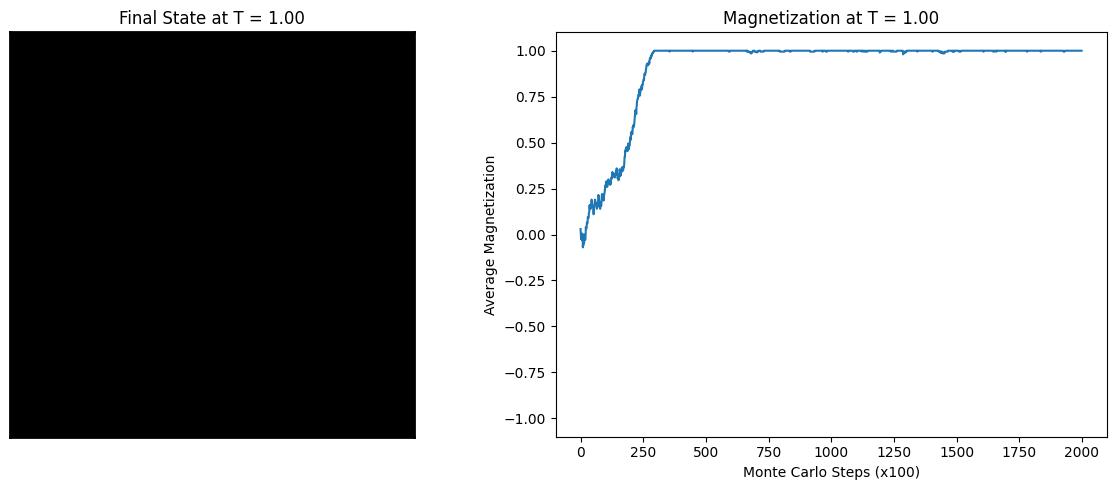

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETER SISTEM
# ==========================================
N = 20                # Ukuran kisi 20x20
MCS = 200000          # Total langkah Monte Carlo
T = 1.0               # SUHU SISTEM

# Inisialisasi Hot Start (Spin acak -1 atau 1) untuk entropi maksimum
grid = np.random.choice([-1, 1], size=(N, N))

mag_history = []      # Array untuk menyimpan nilai magnetisasi

# ==========================================
# 2. ALGORITMA METROPOLIS
# ==========================================
for step in range(MCS):
    # Pilih koordinat kisi secara acak
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)
    s = grid[i, j]

    # Hitung spin tetangga dengan Kondisi Batas Periodik (menggunakan modulo)
    tetangga = grid[(i+1)%N, j] + grid[(i-1)%N, j] + grid[i, (j+1)%N] + grid[i, (j-1)%N]

    # Hitung selisih energi lokal
    delta_E = 2 * s * tetangga

    # Kriteria penerimaan Metropolis
    if delta_E < 0:
        s *= -1 # Terima pembalikan spin
    elif np.random.rand() < np.exp(-delta_E / T):
        s *= -1 # Terima dengan probabilitas tertentu

    grid[i, j] = s # Update kisi

    # Catat rata-rata magnetisasi setiap 100 langkah
    if step % 100 == 0:
        mag_history.append(np.sum(grid) / (N**2))

    # ==========================================
# 3. VISUALISASI HASIL
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Keadaan Akhir Kisi
# Tambahkan border/garis tepi agar kalau hasilnya putih (-1) tetap terlihat kotaknya
axes[0].imshow(grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f"Final State at T = {T:.2f}")
# Kita hilangkan axis ('off'), tapi kita bisa akali agar tidak menyatu dengan background
axes[0].set_xticks([])
axes[0].set_yticks([])
for spine in axes[0].spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Plot 2: Riwayat Magnetisasi
# Ubah Sumbu X agar range-nya 0 sampai 2000 (menyesuaikan panjang mag_history)
axes[1].plot(range(len(mag_history)), mag_history, color='tab:blue', linewidth=1.5)
axes[1].set_title(f"Magnetization at T = {T:.2f}")
axes[1].set_xlabel("Monte Carlo Steps (x100)")
axes[1].set_ylabel("Average Magnetization")
axes[1].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()